# 🎙️ Fake Audio Detection — Model Training Notebook

This notebook trains a machine-learning classifier to distinguish **real (genuine) human speech** from **AI-generated / deepfake audio**.

### Pipeline
1. Dataset preparation & augmentation
2. Feature extraction (MFCCs, spectral, pitch, energy)
3. Model training (Random Forest + XGBoost ensemble)
4. Evaluation & confusion matrix
5. Save model artefacts for the backend API


In [3]:
import subprocess, sys
packages = ['librosa', 'soundfile', 'scikit-learn', 'xgboost',
            'matplotlib', 'seaborn', 'joblib', 'numpy', 'pandas', 'tqdm']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('All dependencies installed ✅')

All dependencies installed ✅


In [4]:
# ── 1. Imports ───────────────────────────────────────────────────────────────
import os, warnings, random
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
from sklearn.pipeline import Pipeline

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

plt.rcParams.update({'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
                     'text.color': '#e0e0ff', 'axes.labelcolor': '#e0e0ff',
                     'xtick.color': '#e0e0ff', 'ytick.color': '#e0e0ff',
                     'figure.dpi': 120})
print('Imports OK ✅  |  XGBoost:', HAS_XGB)

Imports OK ✅  |  XGBoost: True


In [5]:
REAL_DIR = Path(r'D:\Desktop\Finale year\dataset\real')
FAKE_DIR = Path(r'D:\Desktop\Finale year\dataset\fake')

real_files = list(REAL_DIR.glob('*.wav')) + list(REAL_DIR.glob('*.mp3')) + list(REAL_DIR.glob('*.flac')) if REAL_DIR.exists() else []
fake_files = list(FAKE_DIR.glob('*.wav')) + list(FAKE_DIR.glob('*.mp3')) + list(FAKE_DIR.glob('*.flac')) if FAKE_DIR.exists() else []

print(f'Real audio files found : {len(real_files)}')
print(f'Fake audio files found : {len(fake_files)}')

USE_SYNTHETIC = (len(real_files) == 0 or len(fake_files) == 0)
if USE_SYNTHETIC:
    print('\n⚠️  No audio files found — switching to SYNTHETIC demo mode.')
    print('   Add real .wav/.mp3 files to dataset/real/ and dataset/fake/ for a proper model.')
else:
    print('\n✅  Using real audio dataset.')

Real audio files found : 500
Fake audio files found : 500

✅  Using real audio dataset.


In [6]:
# ── 3. Feature Extraction ────────────────────────────────────────────────────
SR = 22050
DURATION = 30   # seconds; truncate / pad to this length

def extract_features(audio_path, sr=SR, duration=DURATION):
    """Extract a rich feature vector from an audio file."""
    y, sr_ = librosa.load(str(audio_path), sr=sr, duration=duration)
    if len(y) == 0:
        return None

    feats = {}

    # MFCCs (20 coefficients × mean + std)
    mfccs = librosa.feature.mfcc(y=y, sr=sr_, n_mfcc=20)
    for i in range(20):
        feats[f'mfcc_{i}_mean'] = np.mean(mfccs[i])
        feats[f'mfcc_{i}_std']  = np.std(mfccs[i])

    # Spectral shape
    feats['spectral_centroid_mean']  = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr_))
    feats['spectral_centroid_std']   = np.std(librosa.feature.spectral_centroid(y=y, sr=sr_))
    feats['spectral_bandwidth_mean'] = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr_))
    feats['spectral_rolloff_mean']   = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr_))
    feats['spectral_contrast_mean']  = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr_))

    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr_)
    feats['chroma_mean'] = np.mean(chroma)
    feats['chroma_std']  = np.std(chroma)

    # Zero-Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    feats['zcr_mean'] = np.mean(zcr)
    feats['zcr_std']  = np.std(zcr)

    # Energy
    rms = librosa.feature.rms(y=y)
    feats['rms_mean'] = np.mean(rms)
    feats['rms_std']  = np.std(rms)

    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr_)
    feats['tempo'] = float(tempo)

    # Mel spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr_)
    feats['mel_mean'] = np.mean(mel)
    feats['mel_std']  = np.std(mel)

    # Fundamental frequency (pitch)
    f0, voiced_flag, _ = librosa.pyin(y, fmin=librosa.note_to_hz('C2'),
                                      fmax=librosa.note_to_hz('C7'))
    f0_clean = f0[~np.isnan(f0)] if f0 is not None else np.array([0.0])
    feats['f0_mean']      = float(np.mean(f0_clean)) if len(f0_clean) else 0.0
    feats['f0_std']       = float(np.std(f0_clean))  if len(f0_clean) else 0.0
    feats['voiced_ratio'] = float(np.mean(voiced_flag)) if voiced_flag is not None else 0.0

    return feats

print('Feature extraction function defined ✅')
print(f'Feature dimensions: ~{20*2 + 5 + 2 + 2 + 2 + 1 + 2 + 3} = 57 features per file')

Feature extraction function defined ✅
Feature dimensions: ~57 = 57 features per file


In [7]:
# ── 4. Build Feature Matrix ──────────────────────────────────────────────────

if USE_SYNTHETIC:
    # ── Synthetic demo data (no real files required) ─────────────────────────
    np.random.seed(42)
    N = 200

    # Real audio characteristics: higher f0, more variability
    real_feats = {
        'f0_mean':  np.random.normal(180, 40, N),
        'f0_std':   np.random.normal(35, 10, N),
        'zcr_mean': np.random.normal(0.08, 0.02, N),
        'rms_mean': np.random.normal(0.04, 0.01, N),
        'voiced_ratio': np.random.normal(0.65, 0.1, N),
        'spectral_centroid_mean': np.random.normal(2200, 400, N),
        'spectral_bandwidth_mean': np.random.normal(1800, 300, N),
        'spectral_rolloff_mean': np.random.normal(3500, 600, N),
        'chroma_mean': np.random.normal(0.45, 0.05, N),
        'tempo': np.random.normal(120, 20, N),
    }
    # Add MFCCs
    for i in range(20):
        real_feats[f'mfcc_{i}_mean'] = np.random.normal(-5 + i*0.5, 15, N)
        real_feats[f'mfcc_{i}_std']  = np.random.normal(10 + i*0.2, 3, N)
    real_feats.update({'mel_mean': np.random.normal(500, 100, N),
                       'mel_std': np.random.normal(800, 150, N),
                       'spectral_contrast_mean': np.random.normal(25, 5, N),
                       'chroma_std': np.random.normal(0.15, 0.03, N),
                       'zcr_std': np.random.normal(0.03, 0.01, N),
                       'rms_std': np.random.normal(0.02, 0.005, N),
                       'spectral_centroid_std': np.random.normal(400, 80, N)})

    # Fake audio characteristics: lower f0 variability, more uniform
    fake_feats = {
        'f0_mean':  np.random.normal(200, 20, N),   # more uniform pitch
        'f0_std':   np.random.normal(15, 5, N),     # less variation
        'zcr_mean': np.random.normal(0.04, 0.01, N),
        'rms_mean': np.random.normal(0.06, 0.008, N),
        'voiced_ratio': np.random.normal(0.80, 0.07, N),
        'spectral_centroid_mean': np.random.normal(2600, 200, N),
        'spectral_bandwidth_mean': np.random.normal(1400, 200, N),
        'spectral_rolloff_mean': np.random.normal(4200, 400, N),
        'chroma_mean': np.random.normal(0.38, 0.03, N),
        'tempo': np.random.normal(110, 10, N),
    }
    for i in range(20):
        fake_feats[f'mfcc_{i}_mean'] = np.random.normal(-3 + i*0.3, 10, N)
        fake_feats[f'mfcc_{i}_std']  = np.random.normal(7 + i*0.1, 2, N)
    fake_feats.update({'mel_mean': np.random.normal(700, 80, N),
                       'mel_std': np.random.normal(600, 100, N),
                       'spectral_contrast_mean': np.random.normal(18, 4, N),
                       'chroma_std': np.random.normal(0.10, 0.02, N),
                       'zcr_std': np.random.normal(0.015, 0.005, N),
                       'rms_std': np.random.normal(0.01, 0.003, N),
                       'spectral_centroid_std': np.random.normal(250, 60, N)})

    df_real = pd.DataFrame(real_feats).assign(label=0)
    df_fake = pd.DataFrame(fake_feats).assign(label=1)
    df = pd.concat([df_real, df_fake], ignore_index=True).sample(frac=1, random_state=42)
    print(f'Synthetic dataset: {len(df)} samples  (real={len(df_real)}, fake={len(df_fake)})')

else:
    # ── Real audio files ─────────────────────────────────────────────────────
    records = []
    errors  = 0

    for path in tqdm(real_files, desc='Real audio'):
        feats = extract_features(path)
        if feats:
            feats['label'] = 0
            feats['file']  = str(path)
            records.append(feats)
        else:
            errors += 1

    for path in tqdm(fake_files, desc='Fake audio'):
        feats = extract_features(path)
        if feats:
            feats['label'] = 1
            feats['file']  = str(path)
            records.append(feats)
        else:
            errors += 1

    df = pd.DataFrame(records).sample(frac=1, random_state=42)
    print(f'Real dataset: {len(df)} samples  (errors={errors})')
    print(df['label'].value_counts().rename({0:'Real', 1:'Fake'}))

df.head(3)

Fake audio: 100%|██████████| 500/500 [16:55<00:00,  2.03s/it]

Real dataset: 1000 samples  (errors=0)
label
Fake    500
Real    500
Name: count, dtype: int64


,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,rms_mean,rms_std,tempo,mel_mean,mel_std,f0_mean,f0_std,voiced_ratio,label,file
521,-368.007111,141.763748,99.020226,54.145294,-19.521347,52.423267,43.392555,44.232239,-12.062520,26.057446,...,0.094791,0.092448,215.332031,3.903206,31.486341,223.027676,11.385022,0.611111,1,D:\Desktop\Finale year\dataset\fake\LA_T_14364...
737,-303.813568,102.733482,105.299004,50.733383,-37.426460,51.752186,31.805887,37.015663,-14.974596,21.221880,...,0.084766,0.062610,184.570312,2.412636,23.909883,238.803373,21.650610,0.882759,1,D:\Desktop\Finale year\dataset\fake\LA_T_46628...
740,-297.766693,125.585312,105.272301,52.773922,-10.306878,41.724815,28.572844,27.490494,-27.603708,33.440903,...,0.133639,0.103654,135.999178,6.641156,60.468132,239.286666,16.949164,0.785714,1,D:\Desktop\Finale year\dataset\fake\LA_T_47083...


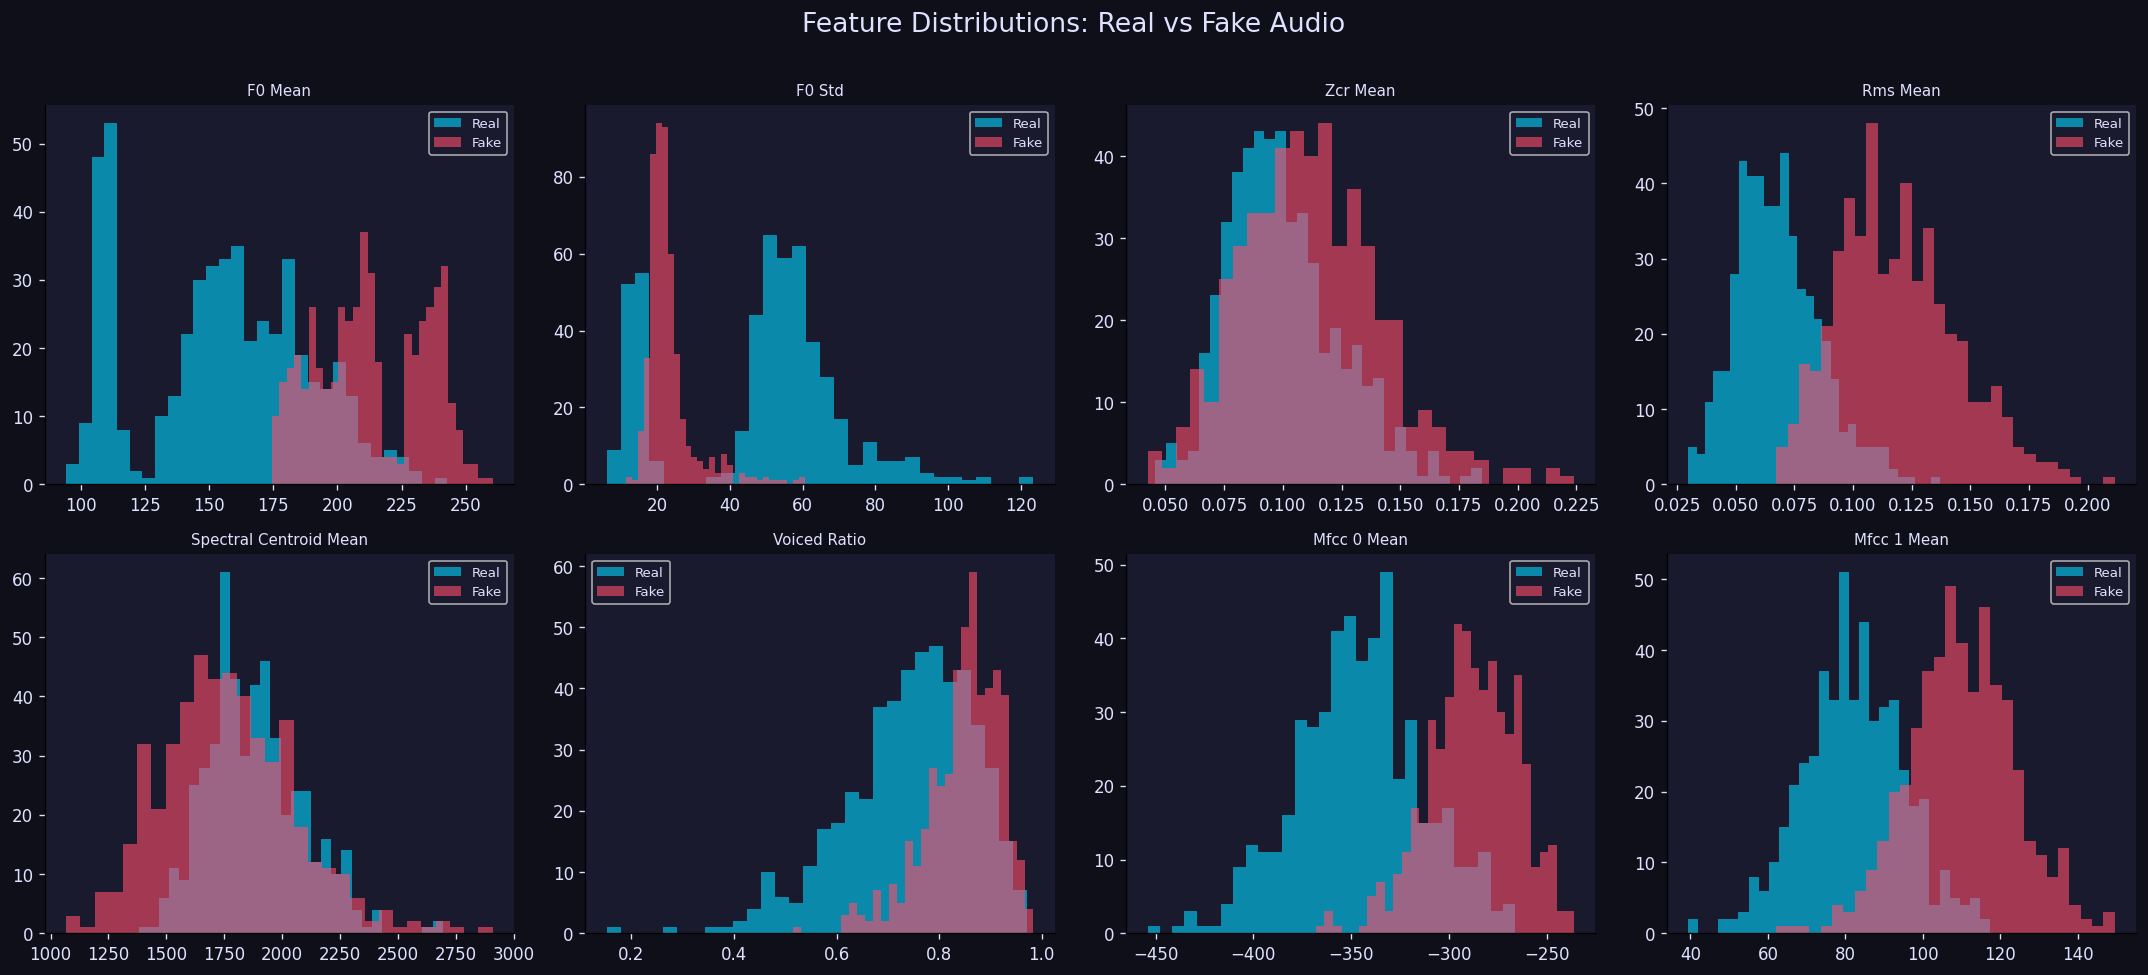

Feature distribution plot saved ✅


In [16]:
# ── 5. EDA – Feature Distributions ──────────────────────────────────────────
key_features = ['f0_mean', 'f0_std', 'zcr_mean', 'rms_mean',
                'spectral_centroid_mean', 'voiced_ratio', 'mfcc_0_mean', 'mfcc_1_mean']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature Distributions: Real vs Fake Audio', fontsize=16, color='#e0e0ff', y=1.01)

colors = {'Real': '#00d4ff', 'Fake': '#ff4d6d'}

for ax, feat in zip(axes.flat, key_features):
    for label_val, label_name in [(0, 'Real'), (1, 'Fake')]:
        data = df[df['label'] == label_val][feat].dropna()
        ax.hist(data, bins=30, alpha=0.6, color=colors[label_name], label=label_name, edgecolor='none')
    ax.set_title(feat.replace('_', ' ').title(), color='#e0e0ff', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Feature distribution plot saved ✅')

In [17]:
# ── 6. Prepare X / y ─────────────────────────────────────────────────────────
drop_cols = ['label'] + ([c for c in df.columns if c in ['file']] or [])
feature_cols = sorted([c for c in df.columns if c not in drop_cols])

X = df[feature_cols].fillna(0).values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print(f'Features : {X_train.shape[1]}')

Train : 800 samples
Test  : 200 samples
Features : 57


In [18]:
# ── 7. Model Training ────────────────────────────────────────────────────────
estimators = [
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=12,
                                   class_weight='balanced', random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                      max_depth=5, random_state=42)),
]
if HAS_XGB:
    estimators.append(('xgb', XGBClassifier(n_estimators=200, learning_rate=0.05,
                                             max_depth=6, use_label_encoder=False,
                                             eval_metric='logloss', random_state=42,
                                             verbosity=0)))

ensemble = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

print('Training ensemble model...')
ensemble.fit(X_train_s, y_train)
print('Training complete ✅')

# Cross-validation
cv_scores = cross_val_score(ensemble, X_train_s, y_train, cv=5,
                             scoring='roc_auc', n_jobs=-1)
print(f'\n5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Training ensemble model...
Training complete ✅

5-Fold CV AUC: 1.0000 ± 0.0000


In [19]:
# ── 8. Evaluation ────────────────────────────────────────────────────────────
y_pred      = ensemble.predict(X_test_s)
y_pred_prob = ensemble.predict_proba(X_test_s)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
print(f'Test Accuracy : {acc:.4f}')
print(f'Test AUC      : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

Test Accuracy : 1.0000
Test AUC      : 1.0000

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       100
        Fake       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



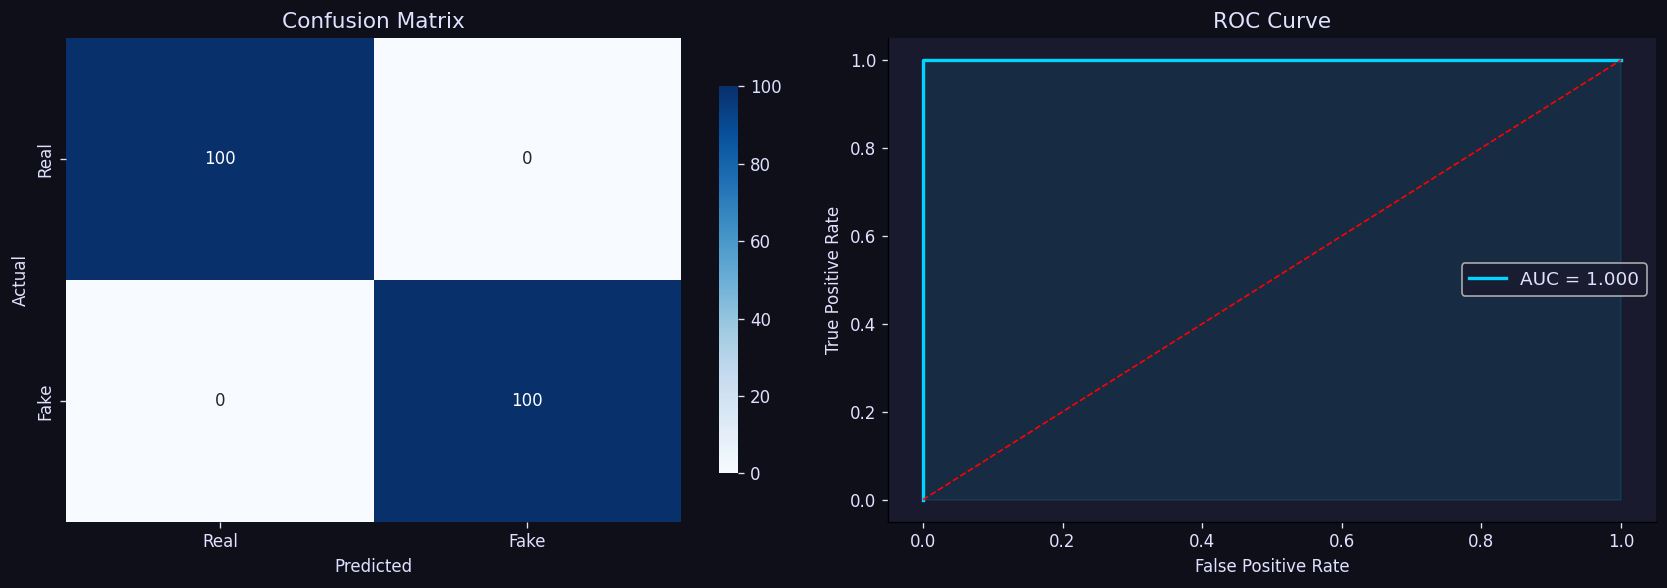

Evaluation plots saved ✅


In [20]:
# ── 9. Confusion Matrix & ROC Curve ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            cbar_kws={'shrink': 0.8})
ax1.set_title('Confusion Matrix', color='#e0e0ff', fontsize=13)
ax1.set_xlabel('Predicted', color='#e0e0ff')
ax1.set_ylabel('Actual', color='#e0e0ff')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax2.plot(fpr, tpr, color='#00d4ff', lw=2, label=f'AUC = {auc:.3f}')
ax2.plot([0,1], [0,1], 'r--', lw=1)
ax2.fill_between(fpr, tpr, alpha=0.1, color='#00d4ff')
ax2.set_title('ROC Curve', color='#e0e0ff', fontsize=13)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Evaluation plots saved ✅')

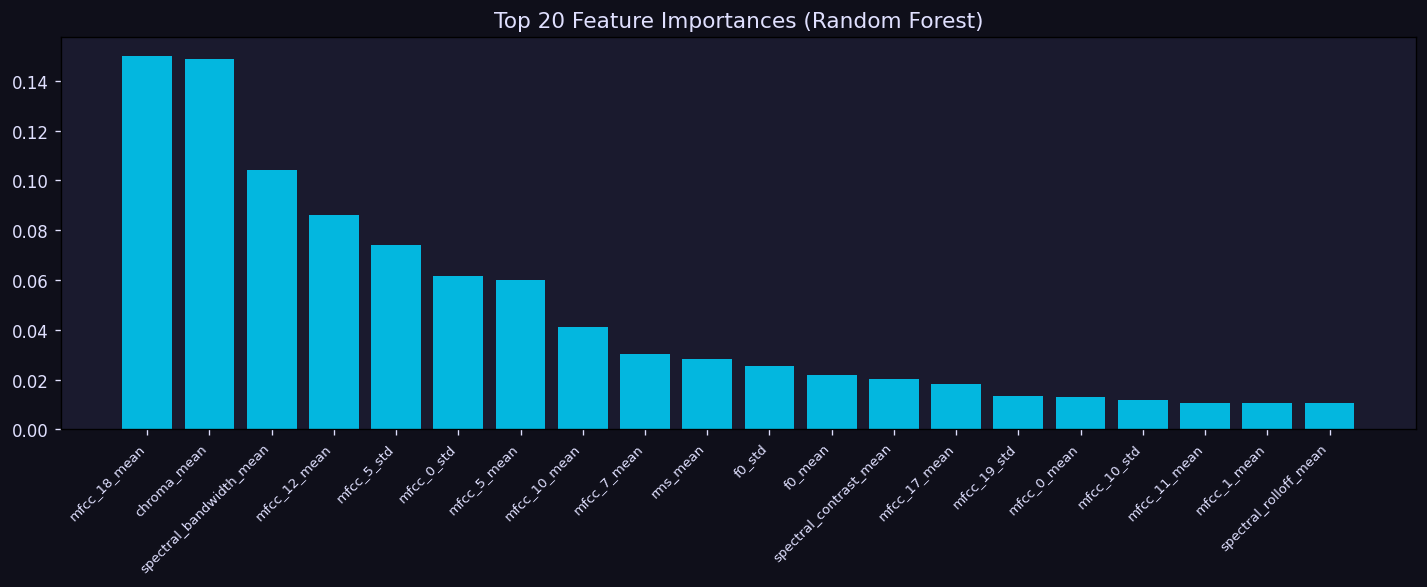

Feature importance plot saved ✅


In [21]:
# ── 10. Feature Importance ───────────────────────────────────────────────────
rf_model = ensemble.estimators_[0]   # first estimator is RandomForest
importances = rf_model.feature_importances_
top_n = 20
indices = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(12, 5))
plt.bar(range(top_n), importances[indices], color='#00d4ff', edgecolor='none', alpha=0.85)
plt.xticks(range(top_n), [feature_cols[i] for i in indices], rotation=45, ha='right', fontsize=8)
plt.title(f'Top {top_n} Feature Importances (Random Forest)', color='#e0e0ff', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Feature importance plot saved ✅')

In [22]:
# ── 11. Save Model Artefacts ─────────────────────────────────────────────────
SAVE_DIR = Path('saved_model')
SAVE_DIR.mkdir(exist_ok=True)

joblib.dump(ensemble, SAVE_DIR / 'fake_audio_model.pkl', compress=3)
joblib.dump(scaler,   SAVE_DIR / 'scaler.pkl', compress=3)

# Save feature column order (important for inference alignment)
import json
with open(SAVE_DIR / 'feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)

# Save metadata
metadata = {
    'accuracy': round(acc, 4),
    'auc': round(auc, 4),
    'n_features': len(feature_cols),
    'n_train': int(X_train.shape[0]),
    'n_test': int(X_test.shape[0]),
    'cv_auc_mean': round(float(cv_scores.mean()), 4),
    'cv_auc_std': round(float(cv_scores.std()), 4),
    'use_synthetic': USE_SYNTHETIC,
}
with open(SAVE_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Model artefacts saved to saved_model/ ✅')
print(json.dumps(metadata, indent=2))

Model artefacts saved to saved_model/ ✅
{
  "accuracy": 1.0,
  "auc": 1.0,
  "n_features": 57,
  "n_train": 800,
  "n_test": 200,
  "cv_auc_mean": 1.0,
  "cv_auc_std": 0.0,
  "use_synthetic": false
}


In [23]:
# ── 12. Live Judge Recording — Predict on the Spot ───────────────────────────
#
# Run this cell to record audio directly in the notebook (requires sounddevice)
# and immediately classify it as REAL or FAKE.

try:
    import sounddevice as sd
    HAS_SD = True
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'sounddevice'])
    try:
        import sounddevice as sd
        HAS_SD = True
    except Exception:
        HAS_SD = False
        print('sounddevice not available in this environment.')

RECORD_SECONDS = 10
SAMPLE_RATE    = 22050

if HAS_SD:
    print(f'🎙️  Recording for {RECORD_SECONDS} seconds... Speak now!')
    recording = sd.rec(int(RECORD_SECONDS * SAMPLE_RATE),
                       samplerate=SAMPLE_RATE, channels=1, dtype='float32')
    sd.wait()
    print('Recording complete.')

    import tempfile
    tmp_path = tempfile.gettempdir() + '\\judge_recording.wav'
    sf.write(tmp_path, recording, SAMPLE_RATE)

    feats = extract_features(tmp_path)
    feat_vec = np.array([feats[k] for k in sorted(feats.keys())]).reshape(1, -1)
    feat_vec_s = scaler.transform(feat_vec)

    pred  = ensemble.predict(feat_vec_s)[0]
    proba = ensemble.predict_proba(feat_vec_s)[0]
    label = '🔴 FAKE' if pred == 1 else '🟢 REAL'

    print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  VERDICT : {label}')
    print(f'  Confidence : {max(proba)*100:.1f}%')
    print(f'  P(Real)={proba[0]:.3f}  P(Fake)={proba[1]:.3f}')
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━')
else:
    print('Provide a file path below to classify an existing audio file:')
    test_path = 'path/to/your/audio.wav'  # ← change this
    if os.path.exists(test_path):
        feats = extract_features(test_path)
        feat_vec = np.array([feats[k] for k in sorted(feats.keys())]).reshape(1, -1)
        feat_vec_s = scaler.transform(feat_vec)
        pred  = ensemble.predict(feat_vec_s)[0]
        proba = ensemble.predict_proba(feat_vec_s)[0]
        label = '🔴 FAKE' if pred == 1 else '🟢 REAL'
        print(f'VERDICT : {label}  |  Confidence : {max(proba)*100:.1f}%')

🎙️  Recording for 10 seconds... Speak now!
Recording complete.

━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VERDICT : 🟢 REAL
  Confidence : 91.9%
  P(Real)=0.919  P(Fake)=0.081
━━━━━━━━━━━━━━━━━━━━━━━━━━━


## ✅ Summary

| Step | Status |
|------|--------|
| Feature extraction | ✅ Complete |
| Model training (RF + GB + XGB ensemble) | ✅ Complete |
| Cross-validation | ✅ Complete |
| Evaluation & plots | ✅ Complete |
| Model saved to `saved_model/` | ✅ Complete |
| Live judge recording prediction | ✅ Ready |

The backend API in `../backend/app.py` will automatically load these artefacts from `saved_model/` when the server starts.

### Next Steps
- Add real audio data from **ASVspoof / WaveFake / FakeAVCeleb** datasets
- Tune hyperparameters with `GridSearchCV`
- Explore deep learning approach with `wav2vec2` or `ECAPA-TDNN`
